In [1]:
import numpy as np

In [2]:
my_list = [1, 2, 3]  # Python list
my_array = np.array(my_list)  # NumPy array
print(my_array * 2)  # Output: [2 4 6] (element-wise operation)

[2 4 6]


In [3]:
celsius = [0, 10, 20, 30]
fahrenheit = np.array(celsius) * 9/5 + 32
print(fahrenheit)  # Output: [32. 50. 68. 86.]

[32. 50. 68. 86.]


In [4]:
import pandas as pd

# Load dataset from URL
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv")
print(df.head())  # Shows first 5 rows

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [5]:
df['sepal_length']

0      5.1
1      4.9
2      4.7
3      4.6
4      5.0
      ... 
145    6.7
146    6.3
147    6.5
148    6.2
149    5.9
Name: sepal_length, Length: 150, dtype: float64

In [6]:
df.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [7]:
mean_sepal = df.groupby('species')['sepal_length'].mean()
print(mean_sepal)

species
setosa        5.006
versicolor    5.936
virginica     6.588
Name: sepal_length, dtype: float64


In [8]:

# Raw data (hourly temperatures over 5 days in °C)
day1 = [12.1, 12.5, 13.0, 14.2, 15.1, 16.0, 15.8, 15.3]
day2 = [11.9, 12.2, 12.8, 14.0, 15.2, 16.1, 15.9, 15.2]
day3 = [10.8, 11.5, 12.3, 13.1, 14.9, 15.8, 15.5, 14.9]
day4 = [9.7, 10.1, 11.0, 12.2, 13.8, 14.7, 14.3, 13.5]
day5 = [8.9, 9.5, 10.3, 11.7, 12.9, 13.8, 13.2, 12.6]

In [ ]:
# Tasks
# Data Conversion
# Combine all days into a single NumPy array (shape = (5, 8)).
all = np.array([day1, day2, day3, day4, day5])
# Convert temperatures to Fahrenheit (°F = °C × 9/5 + 32).
all_f = all * 9 / 5 + 32
# Statistical Analysis
# Calculate the mean temperature for each day.
mean_all = np.mean(all, axis=1)
# Find the daily temperature range (max - min) for all days.
all_range = np.max(all, axis=1) - np.min(all, axis=1)
# Identify which hour had the highest average temperature across all days.
hottest_hour = np.argmax(np.mean(all, axis=0))
# Data Filtering
# Create a masked array showing only temperatures > 15°C in the original data.
day1_15 = np.ma.masked_where(all <= 15, all)
# Count how many measurements exceeded 14°C each day.
count = np.sum(all > 14, axis=1)



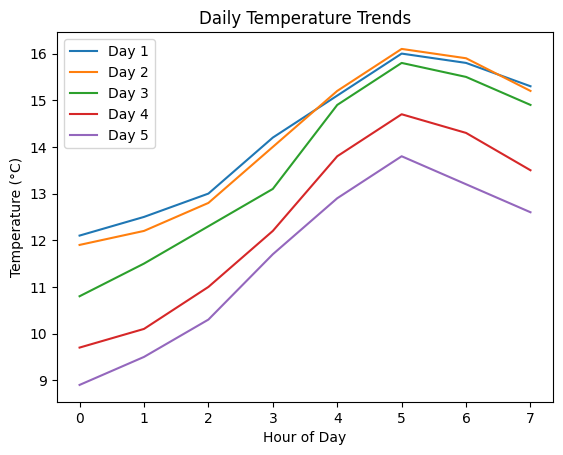

In [54]:
# Visualisation (Bonus)
# Use matplotlib to plot hourly temperature trends for all days.

import matplotlib.pyplot as plt

plt.plot(all.T)
plt.xlabel("Hour of Day")
plt.ylabel("Temperature (°C)")
plt.title("Daily Temperature Trends")
plt.legend(["Day 1", "Day 2", "Day 3", "Day 4", "Day 5"])
plt.show()

In [55]:
import pandas as pd

In [ ]:
df = pd.read_csv("scores.csv")

,student_id,name,math_score,physics_score,chemistry_score,attendance
0,1,Alex,85,76,90,0.92
1,2,Brian,72,88,74,0.85
2,3,Clara,90,82,95,0.96


In [62]:
print("First 3 rows:\n", df.head(3))
print("\nData types:\n", df.dtypes)
print("\nSummary stats:\n", df.describe())

First 3 rows:
    student_id   name  math_score  physics_score  chemistry_score  attendance
0           1   Alex          85             76               90        0.92
1           2  Brian          72             88               74        0.85
2           3  Clara          90             82               95        0.96

Data types:
 student_id           int64
name                object
math_score           int64
physics_score        int64
chemistry_score      int64
attendance         float64
dtype: object

Summary stats:
        student_id  math_score  physics_score  chemistry_score  attendance
count    5.000000    5.000000       5.000000         5.000000    5.000000
mean     3.000000   78.600000      78.400000        80.200000    0.878000
std      1.581139    9.044335       6.655825        13.084342    0.068702
min      1.000000   68.000000      71.000000        62.000000    0.780000
25%      2.000000   72.000000      75.000000        74.000000    0.850000
50%      3.000000   78.000

In [63]:
# Task 2: Data cleaning
print("\nMissing values:\n", df.isnull().sum())
df["attendance"] = (df["attendance"] * 100).round(2)  # Convert to %



Missing values:
 student_id         0
name               0
math_score         0
physics_score      0
chemistry_score    0
attendance         0
dtype: int64


In [ ]:
# Calculations
# Add a new column average_score that calculates the mean of all three subjects.
# Add another column performance_rating with these categories:
# "Excellent" if average ≥ 85
# "Good" if 70 ≤ average < 85
# "Needs Improvement" if average < 70

df["average_score"] = df[["math_score", "physics_score", "chemistry_score"]].mean(axis=1).round(2)
df["performance_rating"] = pd.cut(
    df["average_score"],
    bins=[-float("inf"), 70, 85, float("inf")],
    right=False,
    labels=["Needs Improvement", "Good", "Excellent"],
)

,student_id,name,math_score,physics_score,chemistry_score,attendance,average_score,performance_rating
0,1,Alex,85,76,90,92.0,83.67,Good
1,2,Brian,72,88,74,85.0,78.00,Good
2,3,Clara,90,82,95,96.0,89.00,Excellent
3,4,Diana,68,71,62,78.0,67.00,Needs Improvement
4,5,Ethan,78,75,80,88.0,77.67,Good


In [83]:
print("\nHighest math score:", df.loc[df["math_score"].idxmax(), "name"])


Highest math score: Clara


In [85]:
df[["math_score", "physics_score", "chemistry_score"]].mean()

math_score         78.6
physics_score      78.4
chemistry_score    80.2
dtype: float64

In [87]:
df["performance_rating"].value_counts()

performance_rating
Good                 3
Needs Improvement    1
Excellent            1
Name: count, dtype: int64

In [89]:
import matplotlib.pyplot as plt

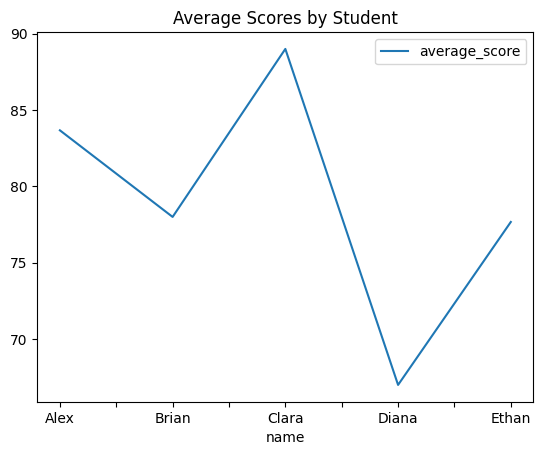

In [93]:
df.plot(x="name", y="average_score", kind="line", title="Average Scores by Student")
plt.show()